In [27]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [28]:
X.info()
X.describe()
X.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X['Population_norm'] = scaler.fit_transform(X[['Population']])


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

print('Train R2:', lr.score(X_train, y_train))
print('Test R2:', lr.score(X_test, y_test))


Train R2: 0.6125511913966952
Test R2: 0.5757877060324507


In [32]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

print('Train R2:', tree.score(X_train, y_train))
print('Test R2:', tree.score(X_test, y_test))


Train R2: 1.0
Test R2: 0.6224882629390598


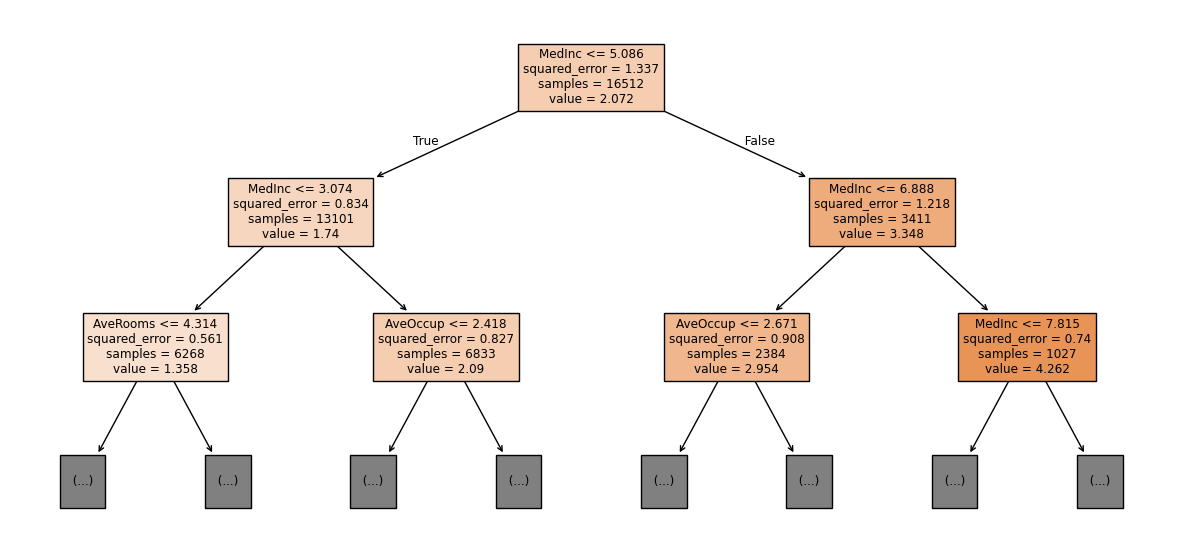

In [33]:
from sklearn import tree as sktree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))
sktree.plot_tree(tree, feature_names=X.columns, max_depth=2, filled=True)
plt.show()


In [34]:
from sklearn.model_selection import GridSearchCV

params = {'max_depth': [3, 5, 7, 9, 12], 'min_samples_split': [2, 5, 10]}
grid = GridSearchCV(DecisionTreeRegressor(random_state=42),
                    param_grid=params,
                    cv=3,
                    scoring='r2')
grid.fit(X_train, y_train)

print('Лучшие параметры:', grid.best_params_)
print('Лучший результат на train:', grid.best_score_)


Лучшие параметры: {'max_depth': 9, 'min_samples_split': 10}
Лучший результат на train: 0.6859723314608522


In [35]:
best_tree = grid.best_estimator_
print('Train R2:', best_tree.score(X_train, y_train))
print('Test R2:', best_tree.score(X_test, y_test))


Train R2: 0.7957995574029089
Test R2: 0.6864187042538994


# Вывод
Решающие деревья показали себя лучще сюдя по метрики r2

инейная регрессия: проста, устойчива, хорошо интерпретируется, но плохо работает с нелинейными зависимостями.

Дерево решений: находит сложные зависимости, интерпретируемо, но склонно к переобучению.

Для быстрых и устойчивых прогнозов лучше регрессия, для сложных зависимостей — дерево.